In [16]:
import os
os.chdir(r'C:\Projects\lmp-forecaster')
print("Working directory:", os.getcwd()) # treat the project root as the home base

Working directory: C:\Projects\lmp-forecaster


In [17]:
import gridstatus 
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

In [18]:
# Initialize MISO
miso = gridstatus.MISO()

# Pull ONE week first - always start small to understand the shape
da_lmp = miso.get_lmp(
    date = "2024-01-01",
    end = "2024-01-08",
    market = gridstatus.Markets.DAY_AHEAD_HOURLY,
    locations = ["ILLINOIS.HUB"]
)

print("Shape:", da_lmp.shape)
print("\nColumns:", da_lmp.columns.tolist())
print("\nFirst few rows:")
da_lmp.head(10)

100%|██████████| 7/7 [00:05<00:00,  1.24it/s]

Shape: (168, 10)

Columns: ['Time', 'Interval Start', 'Interval End', 'Market', 'Location', 'Location Type', 'LMP', 'Energy', 'Congestion', 'Loss']

First few rows:


Value,Time,Interval Start,Interval End,Market,Location,Location Type,LMP,Energy,Congestion,Loss
0,2024-01-01 00:00:00-05:00,2024-01-01 00:00:00-05:00,2024-01-01 01:00:00-05:00,DAY_AHEAD_HOURLY,ILLINOIS.HUB,Hub,22.40,22.96,-0.06,-0.50
1,2024-01-01 01:00:00-05:00,2024-01-01 01:00:00-05:00,2024-01-01 02:00:00-05:00,DAY_AHEAD_HOURLY,ILLINOIS.HUB,Hub,22.05,22.45,-0.06,-0.34
2,2024-01-01 02:00:00-05:00,2024-01-01 02:00:00-05:00,2024-01-01 03:00:00-05:00,DAY_AHEAD_HOURLY,ILLINOIS.HUB,Hub,21.45,22.76,-0.04,-1.27
3,2024-01-01 03:00:00-05:00,2024-01-01 03:00:00-05:00,2024-01-01 04:00:00-05:00,DAY_AHEAD_HOURLY,ILLINOIS.HUB,Hub,20.96,22.37,-0.04,-1.37
4,2024-01-01 04:00:00-05:00,2024-01-01 04:00:00-05:00,2024-01-01 05:00:00-05:00,DAY_AHEAD_HOURLY,ILLINOIS.HUB,Hub,21.33,22.76,-0.03,-1.40
5,2024-01-01 05:00:00-05:00,2024-01-01 05:00:00-05:00,2024-01-01 06:00:00-05:00,DAY_AHEAD_HOURLY,ILLINOIS.HUB,Hub,21.99,22.94,-0.04,-0.91
6,2024-01-01 06:00:00-05:00,2024-01-01 06:00:00-05:00,2024-01-01 07:00:00-05:00,DAY_AHEAD_HOURLY,ILLINOIS.HUB,Hub,24.17,24.47,-0.04,-0.26
7,2024-01-01 07:00:00-05:00,2024-01-01 07:00:00-05:00,2024-01-01 08:00:00-05:00,DAY_AHEAD_HOURLY,ILLINOIS.HUB,Hub,25.59,25.90,-0.06,-0.25
8,2024-01-01 08:00:00-05:00,2024-01-01 08:00:00-05:00,2024-01-01 09:00:00-05:00,DAY_AHEAD_HOURLY,ILLINOIS.HUB,Hub,26.23,26.54,-0.05,-0.26
9,2024-01-01 09:00:00-05:00,2024-01-01 09:00:00-05:00,2024-01-01 10:00:00-05:00,DAY_AHEAD_HOURLY,ILLINOIS.HUB,Hub,25.02,25.30,-0.03,-0.25


In [4]:
print(da_lmp[['Time', 'LMP', 'Energy', 'Congestion','Loss']].to_string())

Value                      Time    LMP  Energy  Congestion  Loss
0     2024-01-01 00:00:00-05:00  22.40   22.96       -0.06 -0.50
1     2024-01-01 01:00:00-05:00  22.05   22.45       -0.06 -0.34
2     2024-01-01 02:00:00-05:00  21.45   22.76       -0.04 -1.27
3     2024-01-01 03:00:00-05:00  20.96   22.37       -0.04 -1.37
4     2024-01-01 04:00:00-05:00  21.33   22.76       -0.03 -1.40
5     2024-01-01 05:00:00-05:00  21.99   22.94       -0.04 -0.91
6     2024-01-01 06:00:00-05:00  24.17   24.47       -0.04 -0.26
7     2024-01-01 07:00:00-05:00  25.59   25.90       -0.06 -0.25
8     2024-01-01 08:00:00-05:00  26.23   26.54       -0.05 -0.26
9     2024-01-01 09:00:00-05:00  25.02   25.30       -0.03 -0.25
10    2024-01-01 10:00:00-05:00  24.93   25.36       -0.02 -0.41
11    2024-01-01 11:00:00-05:00  24.02   24.43       -0.02 -0.39
12    2024-01-01 12:00:00-05:00  23.35   23.74        0.00 -0.39
13    2024-01-01 13:00:00-05:00  22.09   22.99        0.00 -0.90
14    2024-01-01 14:00:00

In [5]:
# Try more recent dates to find what's available
da_lmp_test = miso.get_lmp(
    date="2023-01-01",
    end="2023-01-08",
    market=gridstatus.Markets.DAY_AHEAD_HOURLY,
    locations=["ILLINOIS.HUB"]
)

print("Shape:", da_lmp_test.shape)
print("Date range:", da_lmp_test['Time'].min(), "→", da_lmp_test['Time'].max())


  0%|          | 0/7 [00:00<?, ?it/s]

2026-06-06 11:30:34 - INFO - Downloading LMP data from https://docs.misoenergy.org/marketreports/20230101_da_expost_lmp.csv



 14%|█▍        | 1/7 [00:00<00:03,  1.57it/s]

2026-06-06 11:30:34 - INFO - Downloading LMP data from https://docs.misoenergy.org/marketreports/20230102_da_expost_lmp.csv



 29%|██▊       | 2/7 [00:01<00:03,  1.51it/s]

...


 86%|████████▌ | 6/7 [00:03<00:00,  1.65it/s]

2026-06-06 11:30:37 - INFO - Downloading LMP data from https://docs.misoenergy.org/marketreports/20230107_da_expost_lmp.csv



100%|██████████| 7/7 [00:04<00:00,  1.64it/s]


100%|██████████| 7/7 [00:04<00:00,  1.60it/s]

Shape: (168, 10)
Date range: 2023-01-01 00:00:00-05:00 → 2023-01-07 23:00:00-05:00


## Pulling the full 4-year history (2021-2024)

The one-week probes above use MISO's free daily market reports (`miso.get_lmp`). Those only retain **~2023 onward** — they **404 for 2021-2022**, so they can't give us the full window.

To reach all four years (**2021-2024**) we switch to the **gridstatus.io hosted API**, which keeps deeper history. That pull is wired up in `src/data_pipeline.py` (`fetch_da_lmp`) and only needs a free `GRIDSTATUS_API_KEY`. The next cell pulls live if the key is set, and otherwise falls back to the cached raw CSV the pipeline already wrote.

Why four years instead of two: it spans three distinct regimes — the **2021 Winter Storm Uri** spike, the elevated **2022 energy crisis**, and the calmer **2023-2024** — which is what makes the training-window analysis in the README meaningful.

In [19]:
# ---- Full 4-year history: 2021-2024 ----
# MISO's free daily market reports (the miso.get_lmp path above) only go back to
# ~2023 -- they 404 for 2021-2022. To reach the full 4-year window we use the
# gridstatus.io hosted API, wired up in src/data_pipeline.py. If a key is set we
# pull live; otherwise we load the cached raw CSV that pipeline already produced.
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), 'src'))

RAW_CSV = r"data/raw/da_lmp_illinois_hub_2021_2024.csv"

if os.environ.get("GRIDSTATUS_API_KEY"):
    from data_pipeline import fetch_da_lmp
    # end is exclusive -> 2025-01-01 gives through 2024-12-31
    da_lmp_full = fetch_da_lmp("2021-01-01", "2025-01-01", "ILLINOIS.HUB")
else:
    print("GRIDSTATUS_API_KEY not set -- loading cached raw CSV from the pipeline.")
    da_lmp_full = pd.read_csv(RAW_CSV, parse_dates=["Time"])

print("Shape:", da_lmp_full.shape)
print("Date range:", da_lmp_full['Time'].min(), "->", da_lmp_full['Time'].max())
print("Missing LMP values:", da_lmp_full['LMP'].isna().sum())

GRIDSTATUS_API_KEY not set -- loading cached raw CSV from the pipeline.
Shape: (35064, 10)
Date range: 2021-01-01 00:00:00-05:00 -> 2024-12-31 23:00:00-05:00
Missing LMP values: 0


In [20]:
da_lmp_full.to_csv(r"C:\Projects\lmp-forecaster\data\raw\da_lmp_illinois_hub_2021_2024.csv", index=False)
print("Saved successfully!")

Saved successfully!


In [21]:
# price statistics
print(da_lmp_full['LMP'].describe().round(2))

count    35064.00
mean        39.64
std         27.04
min         -0.90
25%         23.10
50%         31.40
75%         47.53
max        498.89
Name: LMP, dtype: float64


In [22]:
# Negative prices
neg = da_lmp_full[da_lmp_full['LMP'] < 0]
print(f"Negative price hours: {len(neg)} out of {len(da_lmp_full)}")
print(f"That's {len(neg)/len(da_lmp_full)*100:.1f}% of all hours")
print(f"\nMost negative prices:")
print(neg['LMP'].nsmallest(5))

Negative price hours: 5 out of 35064
That's 0.0% of all hours

Most negative prices:
15866   -0.90
16128   -0.55
16129   -0.42
29091   -0.36
15867   -0.21
Name: LMP, dtype: float64


In [23]:
# Price spikes
spike_threshold = da_lmp_full['LMP'].mean() + 3 * da_lmp_full['LMP'].std()
spikes = da_lmp_full[da_lmp_full['LMP'] > spike_threshold]
print(f"Spike threshold: ${spike_threshold:.2f}/MWh")
print(f"Spike hours: {len(spikes)} out of {len(da_lmp_full)}")
print(f"\nTop 5 price spikes:")
print(da_lmp_full.nlargest(5, 'LMP')[['Time', 'LMP', 'Energy', 'Congestion', 'Loss']])

Spike threshold: $120.77/MWh
Spike hours: 667 out of 35064

Top 5 price spikes:
                          Time     LMP  Energy  Congestion   Loss
1135 2021-02-17 07:00:00-05:00  498.89  462.60       64.33 -28.04
1136 2021-02-17 08:00:00-05:00  481.29  451.01       57.74 -27.46
1111 2021-02-16 07:00:00-05:00  423.72  493.89      -48.24 -21.93
1137 2021-02-17 09:00:00-05:00  411.63  428.94        8.88 -26.19
1138 2021-02-17 10:00:00-05:00  396.35  409.61       11.75 -25.01


What the data is telling us:
**February 16–17, 2021 — Winter Storm Uri.** With the full 4-year window, 4 of the top 5 spikes now come from this event, peaking at **$498.89/MWh**. Uri froze gas wellheads across the central US; generators couldn't get fuel and prices exploded across MISO/SPP.
- On Feb 17, Energy hit ~$462 while Congestion added **+$64** and Loss swung to **−$28** — the grid was so stressed that even the loss term (normally near zero) blew out.
- The Jan 16, 2024 polar vortex ($228) and the Aug 2023 heat wave ($219) are the next tier down — same mechanism, smaller magnitude.

## Visualize the Price Patterns

In [24]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

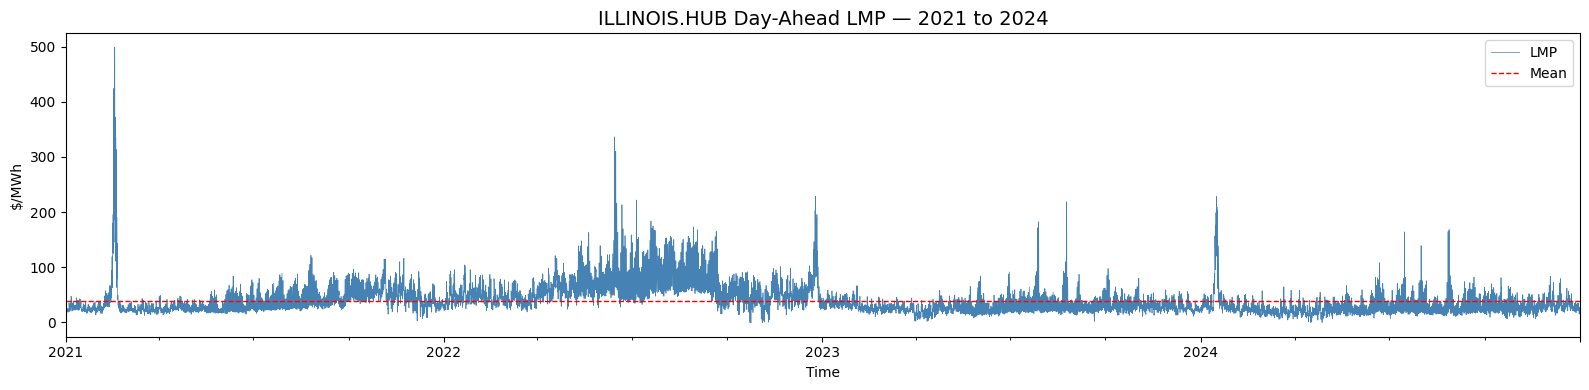

In [25]:
# Full price history
fig, ax = plt.subplots(figsize=(16, 4))
da_lmp_full.set_index('Time')['LMP'].plot(ax=ax, linewidth=0.5, color='steelblue')
ax.set_title('ILLINOIS.HUB Day-Ahead LMP — 2021 to 2024', fontsize=14)
ax.set_ylabel('$/MWh')
ax.axhline(y=da_lmp_full['LMP'].mean(), color='red', linestyle='--', linewidth=1, label='Mean')
ax.legend()
plt.tight_layout()
plt.savefig('results/lmp_full_history.png', dpi=150)
plt.show()

This chart tells:
- **Most of the time** prices cluster in a $20–$50/MWh band — that flat band is "normal".
- **2021** opens with the **Winter Storm Uri** spike (Feb, ~$499/MWh) — the single largest event in the window.
- **2022 is a whole-year regime shift** — the global energy crisis (gas prices) lifts the *entire* year: mean ~$63/MWh vs ~$29 in 2023. Not a one-hour spike, a sustained level change.
- **2023–2024 settle back** to the $27–$29/MWh range, with summer heat-wave spikes (Jul–Sep) and the **Jan 2024 polar vortex** ($228).
- **Prices are not random** — a clear seasonal rhythm plus episodic regime shifts.

What this tells the model:
We need season features (`month`, `is_summer`, `is_winter`), recent price history (`lmp_lag_24h`, `lmp_roll_std`), **and** awareness that a whole-year regime (2022) is different from a one-off spike (2021 Uri). That distinction is exactly why the training-window choice matters — see the README ablation on excluding 2021.

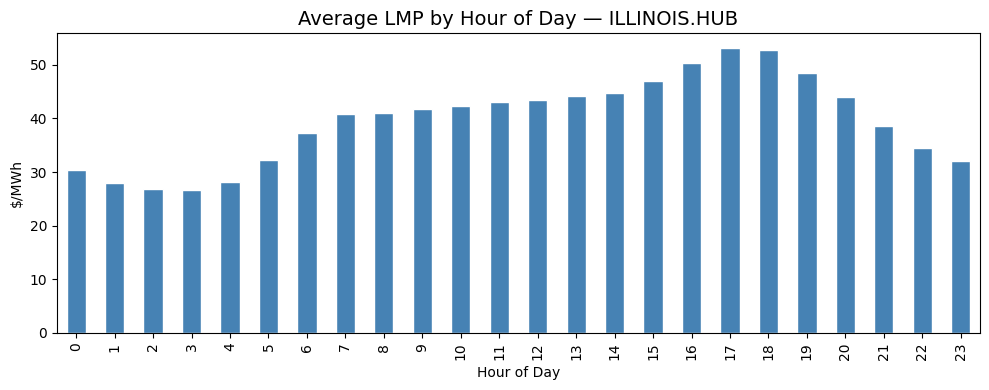

In [26]:
# Average price by hour of day (the daily curve)
df = da_lmp_full.copy()
df['hour'] = df['Time'].dt.hour

hourly_avg = df.groupby('hour')['LMP'].mean()

fig, ax = plt.subplots(figsize=(10, 4))
hourly_avg.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Average LMP by Hour of Day — ILLINOIS.HUB', fontsize=14)
ax.set_xlabel('Hour of Day')
ax.set_ylabel('$/MWh')
ax.set_xticks(range(24))
plt.tight_layout()
plt.savefig('results/lmp_by_hour.png', dpi=150)
plt.show()

This is one of the most important charts in the project. Over 2021–2024 you can see:

Hours 2–4 = cheapest (~$27/MWh) — middle of the night, low demand
Hour 7 = morning ramp (~$41/MWh) — people wake up, factories start
Hours 16–18 = most expensive (~$53/MWh) — evening peak: people get home, cook dinner, lights and AC running while solar generation drops
Hour 23 = falling back (~$32/MWh) — winding down for the night

(The whole curve sits higher than a 2023–2024-only view would, because the 4-year window includes the elevated 2021–2022 prices.)

This "dual hump" shape (morning + evening peak) is the **duck curve** — the fundamental daily rhythm of electricity prices.
What this tells your model: Hour of day is your single most important feature. And it's not linear — hour 17 is not "just a bit more than hour 16." This is why we use sine/cosine encoding.

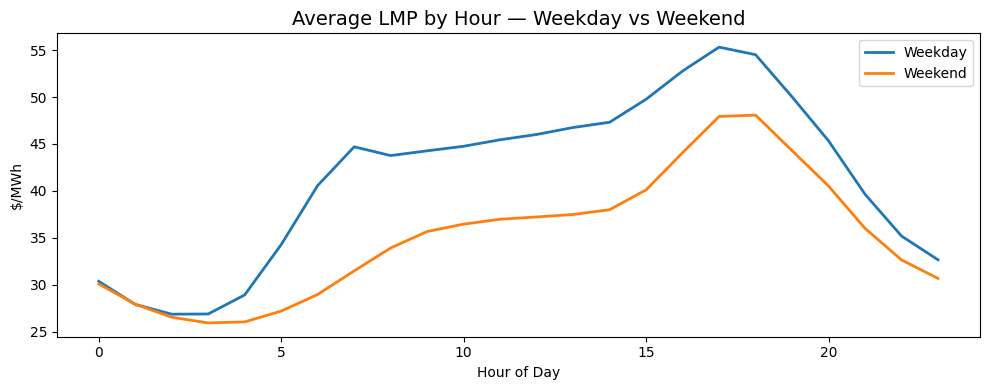

In [27]:
# Weekday v.s. Weedend
df['day_of_week'] = df['Time'].dt.dayofweek
df['is_weekend'] = df['day_of_week'].isin([5, 6])

fig, ax = plt.subplots(figsize=(10, 4))
df.groupby(['hour', 'is_weekend'])['LMP'].mean().unstack().plot(
    ax=ax, linewidth=2
)
ax.set_title('Average LMP by Hour — Weekday vs Weekend', fontsize=14)
ax.set_xlabel('Hour of Day')
ax.set_ylabel('$/MWh')
ax.legend(['Weekday', 'Weekend'])
plt.tight_layout()
plt.savefig('results/lmp_weekday_vs_weekend.png', dpi=150)
plt.show()

Three clear patterns:

Weekdays are consistently more expensive — industrial and commercial load is running
The gap is biggest at hours 6–20 — business hours
Overnight they converge — at 3am, nobody is working anyway
Evening peak (hour 17) is ~$55/MWh on weekdays vs ~$48/MWh on weekends — a ~$7/MWh swing just from the day of week

What this tells your model: `is_weekend` is a strong binary feature. A model that doesn't know what day of week it is will systematically over-predict on weekends and under-predict on weekdays.

## EDA Insights → Feature Mapping

| Observation | Feature It Drives |
|-------------|------------------|
| Strong hourly pattern | `hour_sin`, `hour_cos` |
| Weekday/weekend gap | `is_weekend`, `day_of_week` |
| Summer/winter spikes | `month`, `is_summer`, `is_winter` |
| Prices cluster then spike | `lmp_lag_24h`, `lmp_roll_std` |
| January polar vortex | `temperature`, `extreme_cold_flag` |

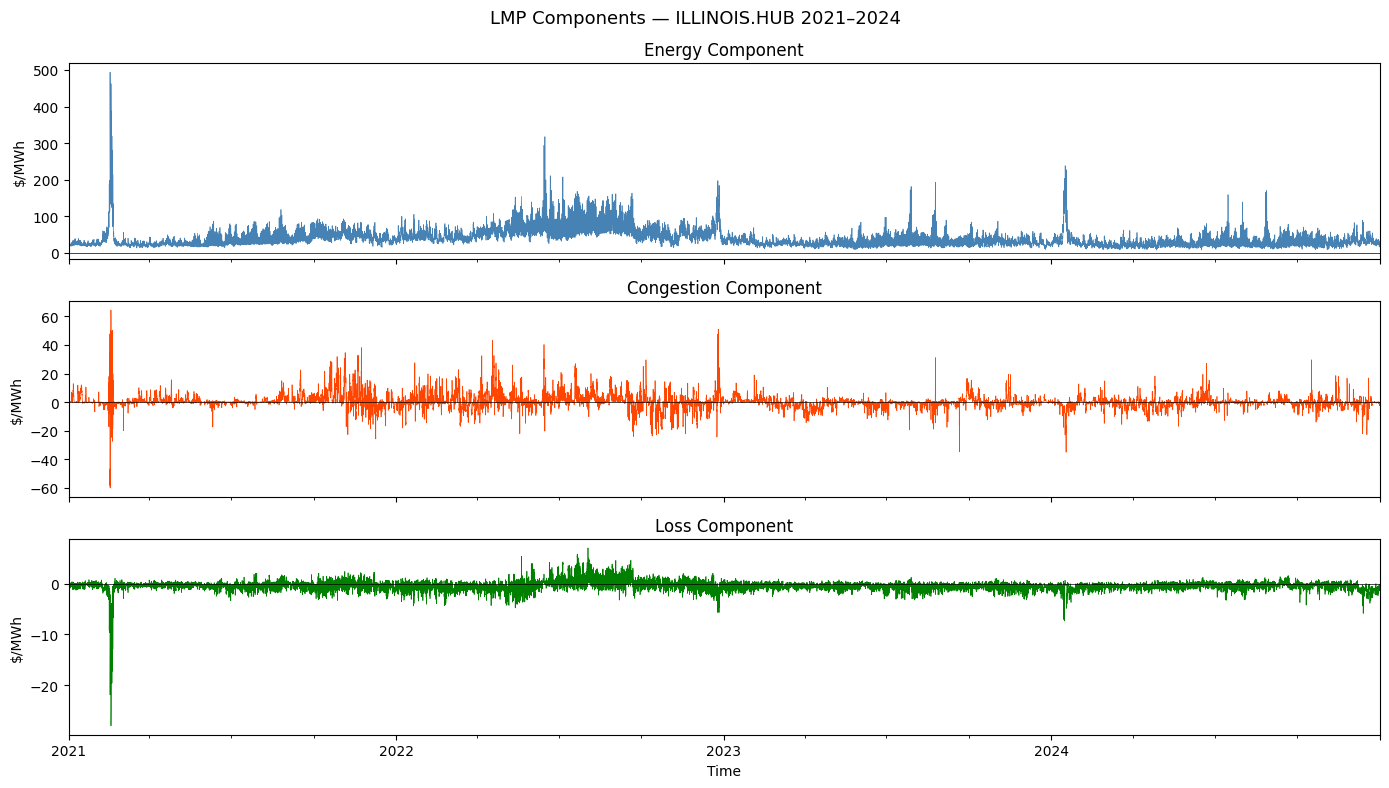

In [28]:
#  it shows the LMP components (Energy vs Congestion vs Loss) which tells you which part is hardest to forecast
df_comp = da_lmp_full.copy()
df_comp['hour'] = df_comp['Time'].dt.hour

fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

components = ['Energy', 'Congestion', 'Loss']
colors = ['steelblue', 'orangered', 'green']

for ax, col, color in zip(axes, components, colors):
    df_comp.set_index('Time')[col].plot(ax=ax, linewidth=0.5, color=color)
    ax.set_ylabel('$/MWh')
    ax.set_title(f'{col} Component')
    ax.axhline(y=0, color='black', linewidth=0.5)

plt.suptitle('LMP Components — ILLINOIS.HUB 2021–2024', fontsize=13)
plt.tight_layout()
plt.savefig('results/lmp_components.png', dpi=150)
plt.show()

Reading the 3 components (2021–2024):
- Energy (Blue) — The predictable one
    - Stays mostly between $20–$50/MWh with clear spikes
    - Spikes are sharp but infrequent — they correspond to system-wide stress events (Uri 2021, the 2022 energy-crisis level shift, summer heat waves)
    - This component follows load and fuel prices closely
    - Most predictable of the three — your model will do best here
- Congestion (Orange) — The Noisy One
    - Oscillates around zero — can be positive OR negative
    - Has sudden large swings — Uri alone drove it from **−$48 to +$64/MWh** within two days
    - No clear seasonal trend — it depends on which transmission lines are congested that specific hour
    - Hardest to forecast — this is where your model will struggle most and where lagged congestion features matter
- Loss (Green) — Usually Irrelevant, Except In The Tail
    - Normally tiny: roughly −$4 to +$1/MWh — essentially noise next to Energy and Congestion
    - **But** under extreme stress it blows out — Uri pushed Loss to ≈ −$28/MWh
    - For a portfolio project you can largely ignore it, while noting that the rare exception co-occurs with the biggest price events

**Total Error = Energy Error (manageable) + Congestion Error (hardest part) + Loss Error (tiny, except in the tail)**